# Pipeline básico de preprocesamiento de imágenes médicas

## Ejemplo didáctico con MRI FLAIR del `teaching_dataset`

Este cuaderno muestra un pipeline reproducible y deliberadamente sencillo para una imagen de **resonancia magnética (MRI)** del dataset de enseñanza.

La idea central es separar dos conceptos:

1. **La imagen adquirida** representa una propiedad física medida por el sistema.
2. **El preprocesamiento** transforma la representación digital para facilitar visualización o análisis posterior.

> **Importante:** este pipeline es educativo. No constituye un protocolo clínico ni debe asumirse como óptimo para todos los estudios de MRI.

### Etapas

**Imagen original → recorte robusto de intensidades → normalización → reducción suave de ruido → mejora de contraste local → redimensionamiento**

También se muestra cómo transformar una **máscara de segmentación** sin alterar sus etiquetas.


## 0. Dependencias

El cuaderno utiliza:

- `numpy`
- `matplotlib`
- `Pillow`
- `scikit-image`

Con `uv`, una opción es instalar:

```bash
uv add numpy matplotlib pillow scikit-image jupyter
```

Se asume que el cuaderno está ubicado en el mismo directorio que:

```text
teaching_dataset/
├── mri/
│   ├── images/
│   ├── masks/
│   └── overlays/
└── ...
```


In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage import exposure, filters, transform

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

## 1. Localizar el dataset

El código busca automáticamente `teaching_dataset` en el directorio actual y en algunos niveles superiores.

Esto evita codificar una ruta absoluta y facilita mover el proyecto entre computadores.


In [13]:
def find_teaching_dataset(start: Path = Path.cwd()) -> Path:
    candidates = [
        start / "teaching_dataset",
        start.parent / "teaching_dataset",
        start.parent.parent / "teaching_dataset",
        start / "data" / "teaching",
        start.parent / "data" / "teaching",
    ]

    for candidate in candidates:
        if (candidate / "mri" / "images").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "No se encontró teaching_dataset. "
        "Ubique el cuaderno junto a la carpeta teaching_dataset "
        "o ajuste manualmente DATASET_ROOT."
    )


DATASET_ROOT = Path(
    "/home/sylph/bioforja/bioforja-projects/pablocaicedor.github.io/presentaciones/TALLERES/teaching_dataset/"
)
MRI_IMAGES = DATASET_ROOT / "mri" / "images"
MRI_MASKS = DATASET_ROOT / "mri" / "masks"

print("Dataset:", DATASET_ROOT)
print("MRI images:", MRI_IMAGES)

Dataset: /home/sylph/bioforja/bioforja-projects/pablocaicedor.github.io/presentaciones/TALLERES/teaching_dataset
MRI images: /home/sylph/bioforja/bioforja-projects/pablocaicedor.github.io/presentaciones/TALLERES/teaching_dataset/mri/images


## 2. Seleccionar una imagen MRI

El dataset de enseñanza contiene imágenes FLAIR derivadas del conjunto MRI seleccionado previamente.

Para mantener el ejemplo reproducible:

- se listan los archivos,
- se ordenan alfabéticamente,
- se selecciona la imagen central de la lista.

Puede cambiar `image_path` manualmente para trabajar con otra imagen.


In [14]:
image_files = sorted(p for p in MRI_IMAGES.glob("*.png") if p.is_file())

if not image_files:
    raise FileNotFoundError(f"No hay PNG en {MRI_IMAGES}")

print(f"Número de imágenes disponibles: {len(image_files)}")
for p in image_files:
    print(" -", p.name)

image_path = image_files[len(image_files) // 2]
print("\nImagen seleccionada:", image_path.name)

Número de imágenes disponibles: 4
 - mask_large.png
 - mask_medium.png
 - mask_small.png
 - slice_without_visible_mask.png

Imagen seleccionada: mask_small.png


## 3. Cargar la imagen

Se convierte explícitamente a escala de grises y posteriormente a `float32`.

Trabajar en punto flotante evita errores por saturación o truncamiento durante operaciones matemáticas.


Shape: (256, 256)
dtype original: uint8
dtype de trabajo: float32
mínimo: 0.0
máximo: 255.0


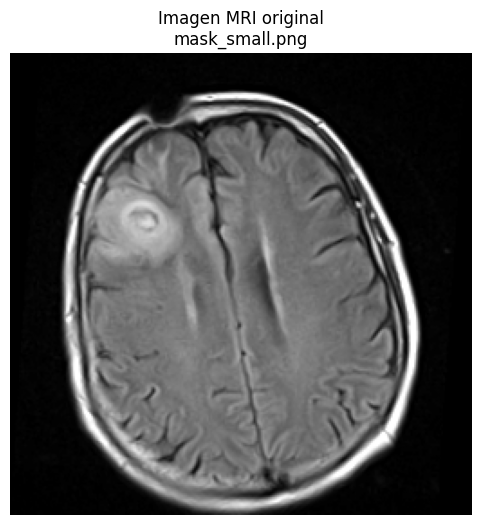

In [15]:
img_u8 = np.array(Image.open(image_path).convert("L"))
img = img_u8.astype(np.float32)

print("Shape:", img.shape)
print("dtype original:", img_u8.dtype)
print("dtype de trabajo:", img.dtype)
print("mínimo:", img.min())
print("máximo:", img.max())

plt.imshow(img)
plt.title(f"Imagen MRI original\n{image_path.name}")
plt.axis("off")
plt.show()

## 4. Inspeccionar la distribución de intensidades

Antes de modificar una imagen conviene observar su histograma.

En MRI, la intensidad **no tiene una escala física universal equivalente a las unidades Hounsfield de CT**. Por ello, operaciones de normalización suelen ser dependientes del estudio, secuencia y objetivo analítico.


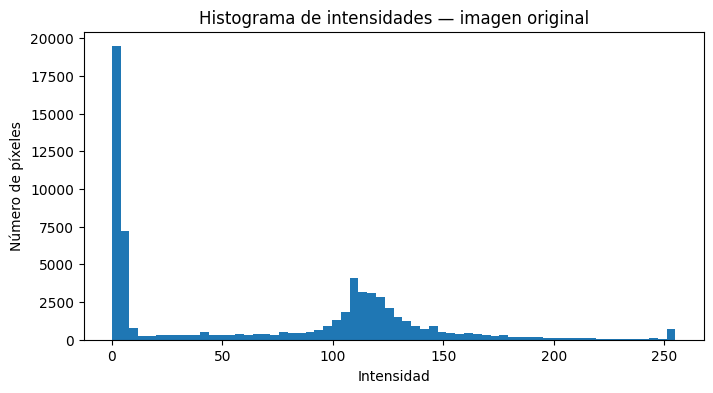

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(img.ravel(), bins=64)
ax.set_title("Histograma de intensidades — imagen original")
ax.set_xlabel("Intensidad")
ax.set_ylabel("Número de píxeles")
plt.show()

## 5. Recorte robusto de intensidades

Los valores extremos pueden dominar una normalización min–max.

Una estrategia didáctica simple es usar percentiles:

- límite inferior: percentil 1
- límite superior: percentil 99

Los valores fuera de ese intervalo se recortan.

Esto **no elimina anatomía** de forma explícita, pero sí modifica la representación de intensidades, por lo que los percentiles deben documentarse.


Percentil 1.0: 0.000
Percentil 99.0: 255.000


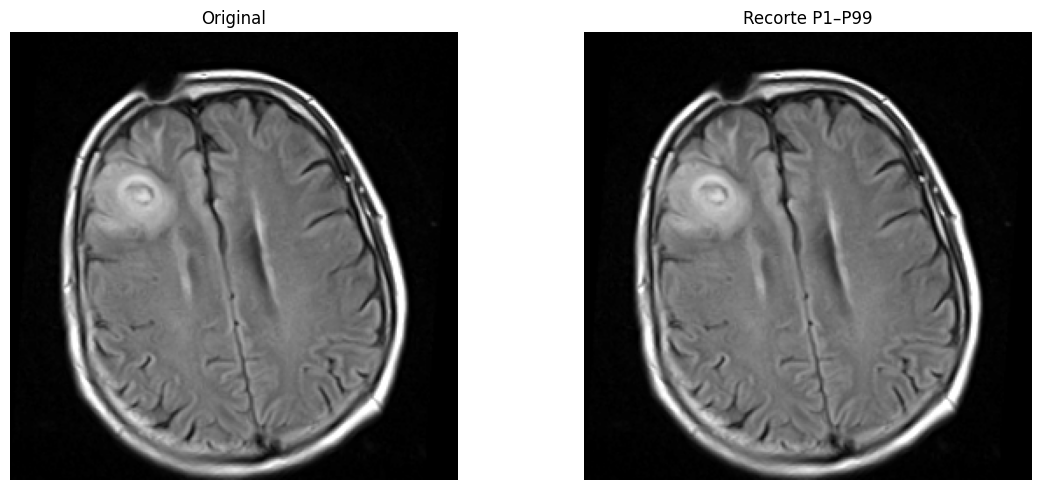

In [17]:
P_LOW = 1.0
P_HIGH = 99.0

low, high = np.percentile(img, [P_LOW, P_HIGH])

img_clipped = np.clip(img, low, high)

print(f"Percentil {P_LOW:.1f}: {low:.3f}")
print(f"Percentil {P_HIGH:.1f}: {high:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_clipped)
axes[1].set_title("Recorte P1–P99")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Normalización a `[0, 1]`

La normalización facilita:

- comparar imágenes en una escala numérica común,
- alimentar algoritmos de procesamiento,
- evitar depender de la profundidad de bits del archivo.

La transformación aplicada es:

\[
I*n = \frac{I - I*{min}}{I*{max} - I*{min}}
\]


mínimo normalizado: 0.0
máximo normalizado: 1.0


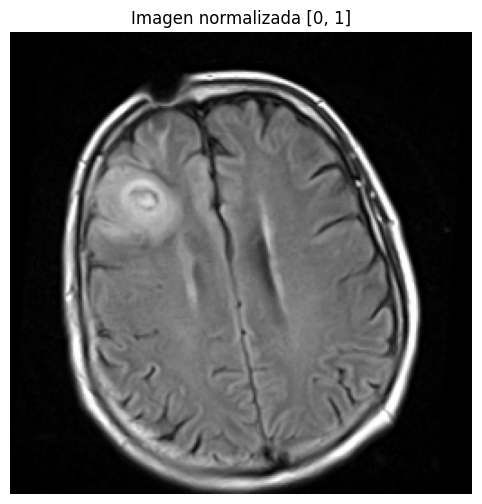

In [18]:
den = img_clipped.max() - img_clipped.min()

if den == 0:
    raise ValueError("La imagen no tiene rango dinámico.")

img_norm = (img_clipped - img_clipped.min()) / den
img_norm = img_norm.astype(np.float32)

print("mínimo normalizado:", img_norm.min())
print("máximo normalizado:", img_norm.max())

plt.imshow(img_norm, vmin=0, vmax=1)
plt.title("Imagen normalizada [0, 1]")
plt.axis("off")
plt.show()

## 7. Reducción suave de ruido

Se aplica un **filtro Gaussiano pequeño**.

El objetivo no es borrar textura, sino ilustrar el compromiso fundamental:

> **Reducir ruido casi siempre implica perder parte del detalle espacial.**

Por eso se usa un `sigma` bajo.


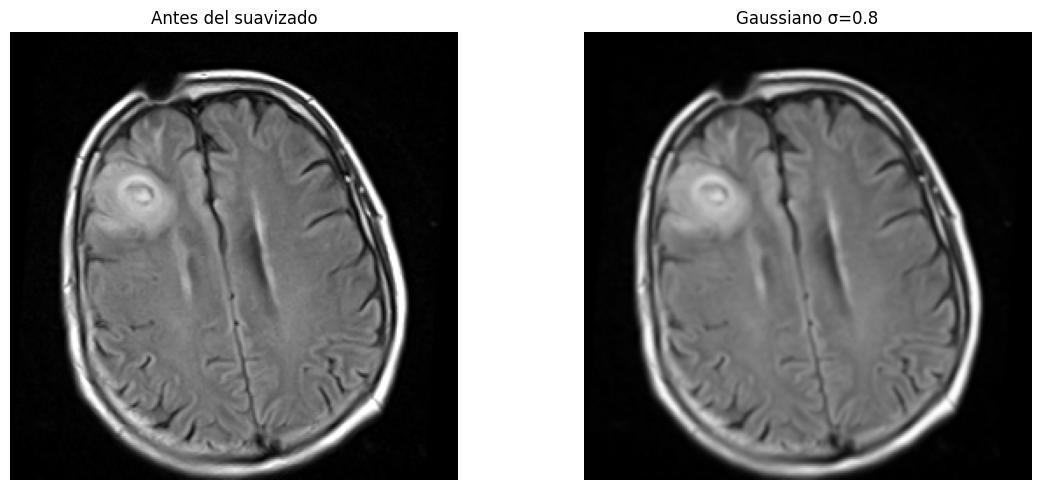

In [19]:
GAUSSIAN_SIGMA = 0.8

img_denoised = filters.gaussian(
    img_norm, sigma=GAUSSIAN_SIGMA, preserve_range=True
).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_norm, vmin=0, vmax=1)
axes[0].set_title("Antes del suavizado")
axes[0].axis("off")

axes[1].imshow(img_denoised, vmin=0, vmax=1)
axes[1].set_title(f"Gaussiano σ={GAUSSIAN_SIGMA}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 8. Mejora de contraste local con CLAHE

CLAHE (_Contrast Limited Adaptive Histogram Equalization_) mejora el contraste por regiones, limitando la amplificación excesiva.

Es útil para demostrar que:

- **mejor contraste visual no significa automáticamente mejor información clínica**;
- una transformación puede facilitar la visualización y, al mismo tiempo, modificar la distribución original de intensidades.

Por eso siempre se conserva la imagen sin procesar.


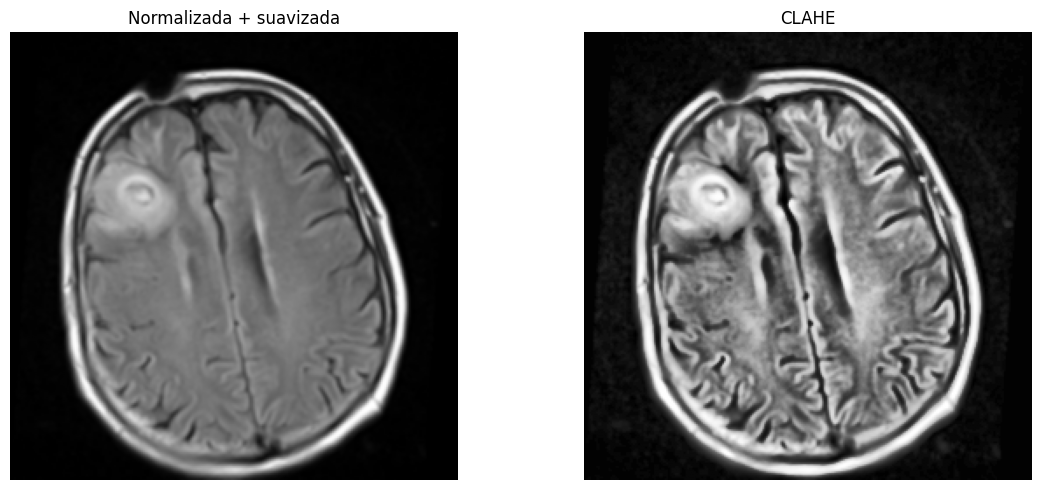

In [20]:
CLAHE_CLIP_LIMIT = 0.02

img_clahe = exposure.equalize_adapthist(
    img_denoised, clip_limit=CLAHE_CLIP_LIMIT
).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_denoised, vmin=0, vmax=1)
axes[0].set_title("Normalizada + suavizada")
axes[0].axis("off")

axes[1].imshow(img_clahe, vmin=0, vmax=1)
axes[1].set_title("CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 9. Redimensionamiento

Muchos modelos de aprendizaje automático necesitan imágenes con dimensiones uniformes.

Aquí se usa `256 × 256` únicamente como tamaño didáctico.

Para imágenes se utiliza interpolación continua y **anti-aliasing**.


Shape original: (256, 256)
Shape final: (256, 256)


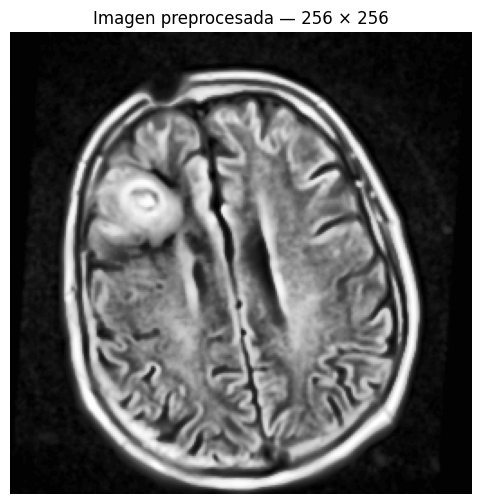

In [21]:
TARGET_SHAPE = (256, 256)

img_resized = transform.resize(
    img_clahe, TARGET_SHAPE, order=1, anti_aliasing=True, preserve_range=True
).astype(np.float32)

print("Shape original:", img.shape)
print("Shape final:", img_resized.shape)

plt.imshow(img_resized, vmin=0, vmax=1)
plt.title("Imagen preprocesada — 256 × 256")
plt.axis("off")
plt.show()

## 10. Ver el pipeline completo

La comparación secuencial permite discutir qué aporta y qué sacrifica cada transformación.


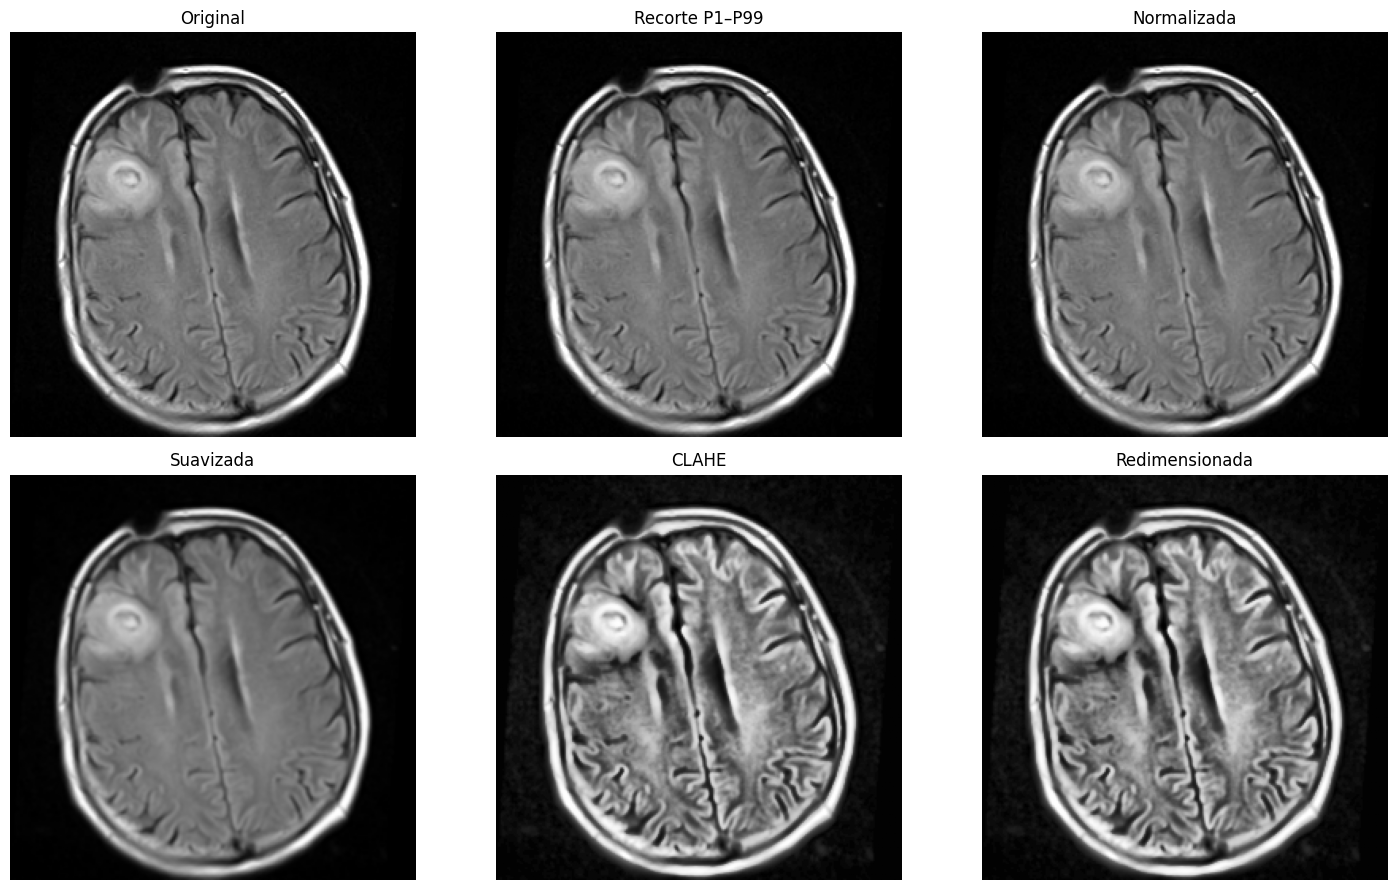

In [22]:
stages = [
    ("Original", img),
    ("Recorte P1–P99", img_clipped),
    ("Normalizada", img_norm),
    ("Suavizada", img_denoised),
    ("CLAHE", img_clahe),
    ("Redimensionada", img_resized),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (title, stage) in zip(axes.ravel(), stages):
    ax.imshow(stage)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Comparación de histogramas

El histograma permite comprobar que el preprocesamiento no es una operación neutra: cambia explícitamente la representación numérica.


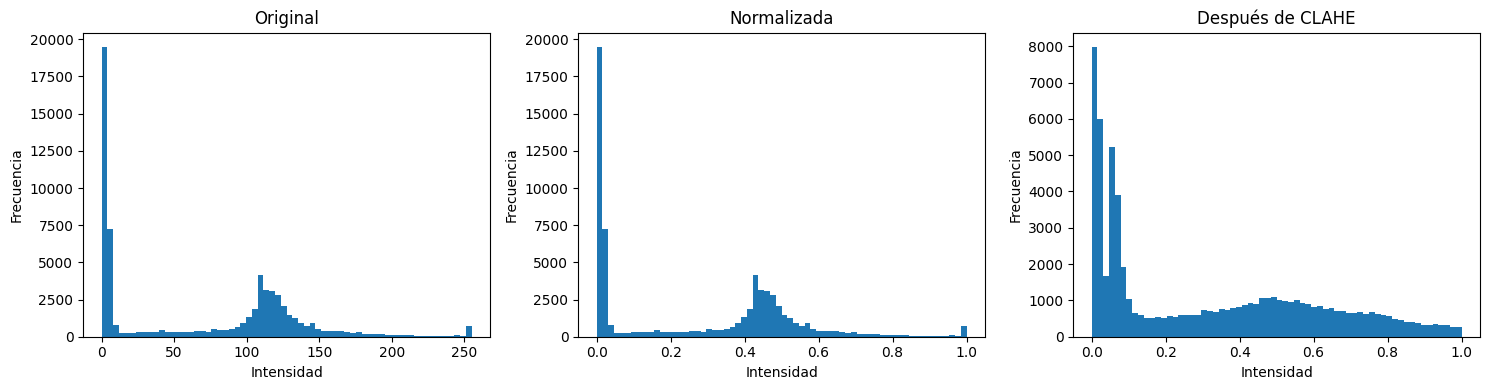

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img.ravel(), bins=64)
axes[0].set_title("Original")

axes[1].hist(img_norm.ravel(), bins=64)
axes[1].set_title("Normalizada")

axes[2].hist(img_clahe.ravel(), bins=64)
axes[2].set_title("Después de CLAHE")

for ax in axes:
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 12. Si existe una máscara: conservar sus etiquetas

Una máscara de segmentación **no debe procesarse como una imagen de intensidad**.

En particular:

- no se aplica CLAHE,
- no se suaviza,
- al redimensionar se usa **vecino más cercano** (`order=0`).

Esto evita crear etiquetas intermedias inexistentes.


Máscara: mask_small_mask.png
Valores originales: [False  True]
Valores después de resize: [False  True]


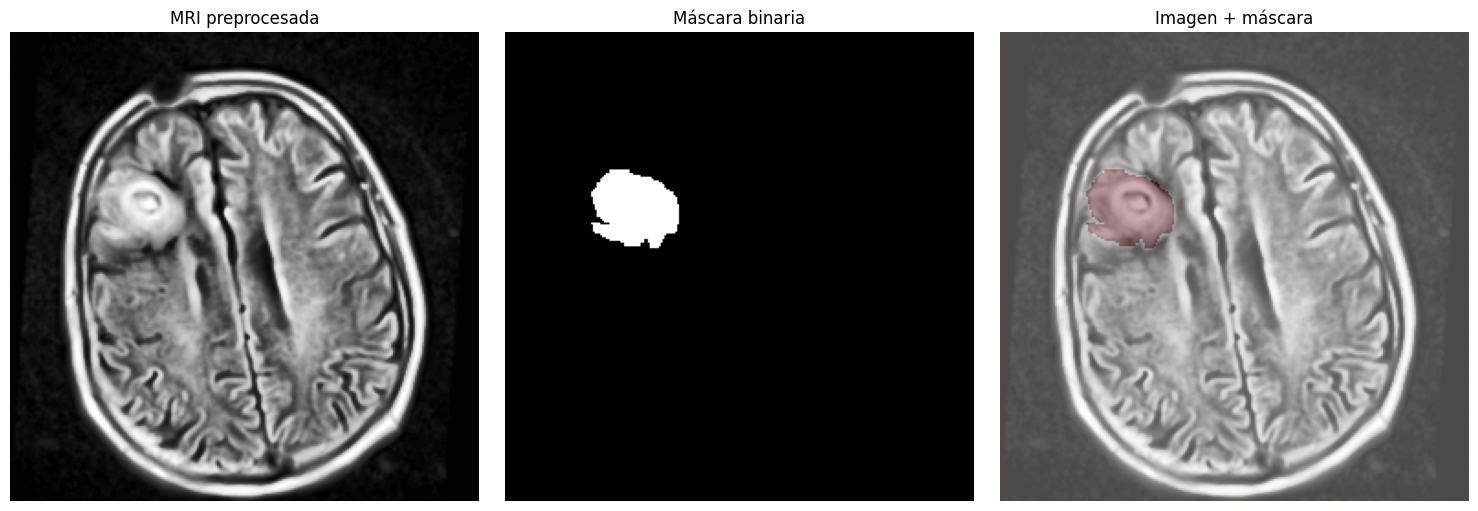

In [24]:
def find_matching_mask(image_path: Path, mask_dir: Path):
    # Primero intenta coincidencias por nombre base.
    candidates = [
        mask_dir / image_path.name,
        mask_dir / image_path.name.replace(".png", "_mask.png"),
        mask_dir / image_path.name.replace("_flair.png", "_mask.png"),
        mask_dir / image_path.name.replace("_image.png", "_mask.png"),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Fallback: buscar términos comunes del nombre.
    stem_tokens = [t for t in image_path.stem.split("_") if t not in {"image", "flair"}]
    for p in sorted(mask_dir.glob("*.png")):
        if stem_tokens and all(token in p.stem for token in stem_tokens[:2]):
            return p

    return None


mask_path = find_matching_mask(image_path, MRI_MASKS)

if mask_path is None:
    print("No se encontró una máscara correspondiente. Se omite esta sección.")
else:
    mask = np.array(Image.open(mask_path).convert("L")) > 0

    mask_resized = (
        transform.resize(
            mask.astype(np.uint8),
            TARGET_SHAPE,
            order=0,
            anti_aliasing=False,
            preserve_range=True,
        )
        > 0
    )

    print("Máscara:", mask_path.name)
    print("Valores originales:", np.unique(mask))
    print("Valores después de resize:", np.unique(mask_resized))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_resized, vmin=0, vmax=1)
    axes[0].set_title("MRI preprocesada")
    axes[0].axis("off")

    axes[1].imshow(mask_resized)
    axes[1].set_title("Máscara binaria")
    axes[1].axis("off")

    axes[2].imshow(img_resized, vmin=0, vmax=1)
    axes[2].imshow(mask_resized, alpha=0.30, cmap="Reds")
    axes[2].set_title("Imagen + máscara")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 13. Exportar el resultado

El resultado derivado se guarda en una carpeta separada.

La imagen original del `teaching_dataset` no se modifica.


In [25]:
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_image = OUTPUT_DIR / "mri_preprocessed.png"

img_export = np.clip(img_resized * 255.0, 0, 255).astype(np.uint8)
Image.fromarray(img_export).save(output_image)

print("Imagen guardada en:")
print(output_image.resolve())

Imagen guardada en:
/home/sylph/bioforja/bioforja-projects/pablocaicedor.github.io/codigo/talleres/outputs/mri_preprocessed.png


## 14. Resumen conceptual

Este ejemplo utilizó una sola modalidad: **MRI FLAIR**.

El pipeline fue:

```text
imagen original
      │
      ▼
inspección
      │
      ▼
recorte robusto P1–P99
      │
      ▼
normalización [0,1]
      │
      ▼
suavizado Gaussiano
      │
      ▼
CLAHE
      │
      ▼
redimensionamiento
      │
      ▼
imagen preparada para análisis
```

### Preguntas para discusión

1. ¿Qué información cambia cuando se normalizan las intensidades?
2. ¿Por qué el suavizado puede ser beneficioso y perjudicial al mismo tiempo?
3. ¿Por qué una máscara necesita interpolación diferente?
4. ¿Sería correcto aplicar exactamente este pipeline a una radiografía, una CT o un ultrasonido?
5. ¿Qué transformaciones deberían definirse a partir de la tarea clínica o del modelo posterior?

### Idea clave

> **Preprocesar no significa “mejorar” una imagen de manera universal. Significa transformarla de forma controlada y documentada para una tarea específica.**


## Referencia conceptual de la clase

El enfoque sigue la idea de estudiar imágenes médicas como señales digitales producidas por sistemas de adquisición: una imagen representa una propiedad física medida y su procesamiento debe interpretarse dentro de la modalidad y del objetivo de análisis.

Para la clase, esta distinción es más importante que memorizar una secuencia fija de filtros.
